In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import math
from cycler import cycler

from scipy.optimize import curve_fit


# Define high-contrast color palette
# 1. Deep Blue, 2. Brick Red, 3. Forest Green, 4. Muted Purple, 5. Safety Orange, 
# 6. Chestnut Brown, 7. Raspberry Pink, 8. Slate Gray, 9. Olive Gold, 10. Teal/Cyan

general_colors = ['#1f77b4','#d62728','#2ca02c','#9467bd','#ff7f0e','#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf' ]
light_colors = ['#0047AB',  '#FF0000',  '#00CC00',  '#9932CC',  '#FF8C00',  '#FF00FF',  '#FFD700',  '#00CED1',  '#FF4500',  '#7FFF00']

# General graph settings
plt.rcParams.update({
    # Font settings
    'font.family': 'sans-serif',          # Universal font family
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'], # Fallback fonts
    # 'font.family': 'serif',          # Cambiato da sans-serif a serif
    # 'font.serif': ['Computer Modern', 'Times New Roman', 'DejaVu Serif'], # Lista di font serif
    'mathtext.fontset': 'cm',        # Imposta i simboli matematici nello stile di LaTeX (Computer Modern
    # 'mathtext.fontset': 'stix',           # Makes LaTeX math symbols match the text font style
    
    # Color cycle settings
    'axes.prop_cycle': cycler(color=light_colors), # Sets the default color sequence for multiple lines
    
    # Size and resolution
    'font.size': 14,                      # General font size
    'axes.labelsize': 14,                 # Size of axis labels (x, y)
    'axes.titlesize': 16,                 # Size of the plot title
    'legend.fontsize': 12,                # Legend font size
    
    # Line and marker aesthetics
    'lines.linewidth': 2,                 # Line width
    'lines.markersize': 5,                # Marker size
    'figure.figsize': (10, 6),            # Default figure size
    
    # Grid settings
    'axes.grid': True,                    # Enable grid by default
    'grid.alpha': 0.4,                    # Make grid slightly transparent
    'grid.linestyle': '--',               # Dashed grid style
    'errorbar.capsize': False                 # Add caps to error bars
})

# Exercise 02


## Exercise 02.1
### Assignment
- Compute the following 1D integral via Monte Carlo 
$$I = \int_0^1 \frac{\pi}{2}\cos(\pi x/2) dx = 1$$
1. sampling a uniform distribution in $[0,1]$
2. using importance sampling (i.e. sampling a non-uniform probability in $[0,1]$)
Show a picture of both your estimations of $I$ and their uncertainties with a large number of *throws* $M$ (e.g. $M\ge 10^4$) as a function of the number of blocks, $N$</font>.

### Solution
In this exercise, I evaluate the following 1D integral using Monte Carlo techniques:
$$I = \int_0^1 \frac{\pi}{2}\cos\left(\frac{\pi}{2} x\right) dx = 1$$

**Uniform Sampling:** Sampling points are generated by sampling a uniform distribution in the interval $[0, 1)$.

**Importance Sampling:** Sampling points are generated according to a specific probability density function (PDF) $p(x)$ designed to mimic the behavior of the integrand, thereby reducing the variance. We chose the normalized PDF:
   $$p(x) = 2(1-x)$$
   which was obtained by performing a Taylor expansion of the integrand function around $x = 1$.

As usual, the statistical uncertainties are estimated using the **Data Blocking** method.


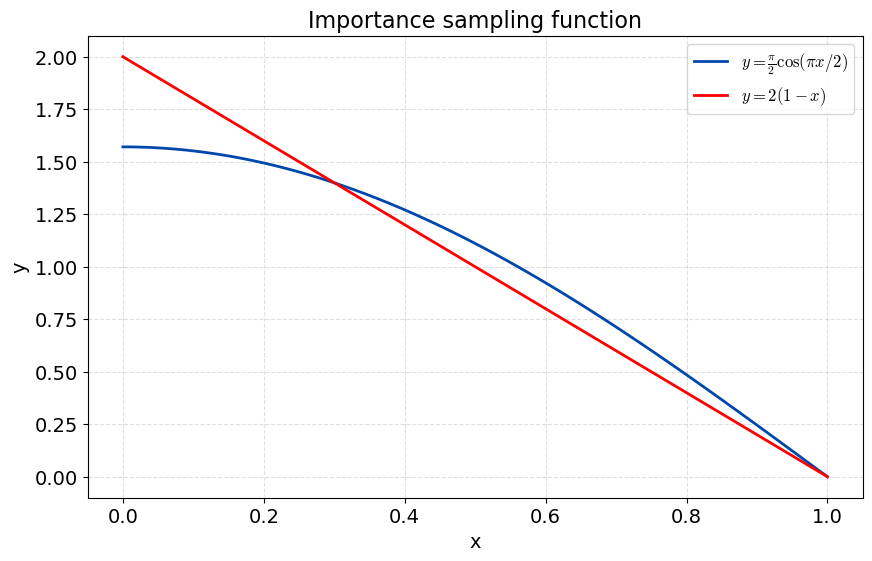

In [3]:
# Define data
x = np.linspace(0, 1, 100)
y_1 = (np.pi / 2) * np.cos(np.pi * x / 2)
y_2 = 2*(1-x)
# Graph
plt.plot(x, y_1, label=r'$y = \frac{\pi}{2}\cos(\pi x/2)$')
plt.plot(x, y_2, label=r'$y = 2(1-x)$')


# Estet
plt.title('Importance sampling function')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Here i report the function used for the importance sampling, $y = p(x) = 2(1-x)$.

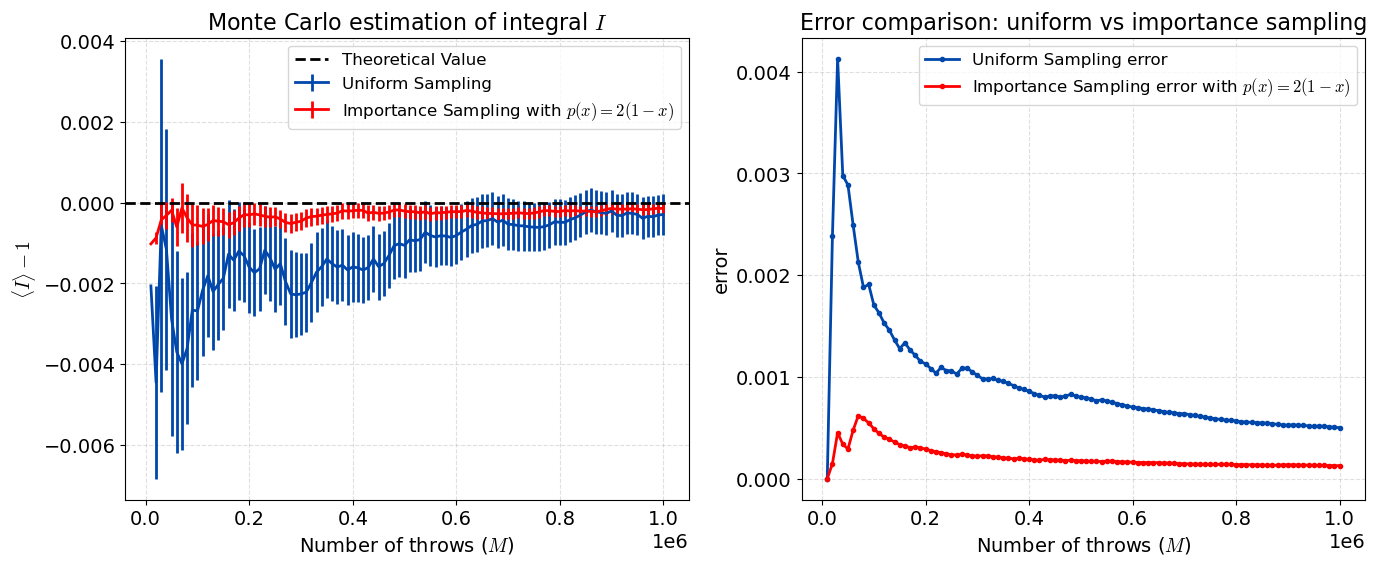

In [4]:
# Load data files
data_unif = np.loadtxt("Esercizio_02.1/risultati_02.1.dat")
data_is = np.loadtxt("Esercizio_02.1/risultati_02.2.dat")

# Extract columns (Uniform Sampling)
x_unif = data_unif[:, 0]
y_unif = data_unif[:, 1]
err_unif = data_unif[:, 2]

# Extract columns (Importance Sampling)
x_is = data_is[:, 0]
y_is = data_is[:, 1]
err_is = data_is[:, 2]


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16,6))
axes
# Uniform Sampling plot
axes[0].errorbar(x_unif, y_unif - 1, yerr=err_unif, 
             label='Uniform Sampling')

# Importance Sampling plot
axes[0].errorbar(x_is, y_is - 1, yerr=err_is, 
             label=r'Importance Sampling with $p(x)=2(1-x)$')

# Reference line for the theoretical value (I = 1, so I - 1 = 0)
axes[0].axhline(y=0, color='black', linestyle='--', label='Theoretical Value')

# Titles and Labels
axes[0].set_title(r'Monte Carlo estimation of integral $I$')
axes[0].set_xlabel(r'Number of throws ($M$)')
axes[0].set_ylabel(r'$\langle I \rangle - 1$')
axes[0].legend(loc='best')

# Uniform Sampling plot
axes[1].plot(x_unif, err_unif, marker='o', markersize=3,
             label='Uniform Sampling error')

# Importance Sampling plot
axes[1].plot(x_is, err_is, marker='o', markersize=3,
             label=r'Importance Sampling error with $p(x)=2(1-x)$')

# Titles and Labels
axes[1].set_title(r'Error comparison: uniform vs importance sampling')
axes[1].set_xlabel(r'Number of throws ($M$)')
axes[1].set_ylabel(r'error')
axes[1].legend(loc='best')


From the data it is clear that the Importance Sampling method increases drastically the precision of the simulation. This behaviour is expected and it is due to the fact that the data are extracted from a distribution that resembles the target one.

## Exercise 02.2
### Assignment
- 3D Random Walks (RW) on a cubic lattice and in the continuum. Repeat many times (e.g. say $10^4$) the simulation of a random walk in 3D always starting at the origin
1. on a cubic lattice with lattice constant $a=1$; at each discrete time the walker makes a forward or backward step of length equal to $a$ in one of the 3 principal directions of the lattice: $x$, $y$ or $z$
2. in the continuum; at each discrete time the walker makes a step of length equal to $a(=1)$ along a **random direction** obtained by sampling **uniformly** the solid angle: $\theta \in [0,\pi]$ and $\phi \in [0,2\pi]$

Show a picture of $\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$ for both RWs</span>, with their statistical uncertainties, as function of the step $i\in [0,10^2]$.

Suggestion: divide your $M$ throws into a reasonable number of blocks, compute $\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$ as function of the step $i\in [0,10^2]$ in each block and use these values (for fixed $i$) to obtain the average value and its statistical uncertainty.

Note that you could try to fit both results with a function like $f(N)=k\sqrt{N}$. Do your results indicate a diffusive behavior?

### Solution
In the second exercise, we simulate a 3D Random Walk (RW) consisting of $N=100$ steps to study its statistical properties and verify the standard diffusive behavior. 
We simulate the RW in two different spaces, both with a step length $a=1$:
1. **Discrete Space:** The walker moves on a simple cubic lattice. At each discrete time step, it takes a forward or backward step along one of the three principal axes ($x$, $y$, or $z$).
2. **Continuous Space:** The walker moves in the continuum. At each step, the direction is chosen randomly by uniformly sampling the solid angle ($\theta \in [0,\pi]$ and $\phi \in [0,2\pi]$).

For both models, we evaluate the root-mean-square (RMS) distance from the origin, $\sqrt{\langle |\vec{r}_i|^2 \rangle_{RW}}$, as a function of the step index $i \in [0, 100]$. 

To correctly estimate the statistical uncertainties via the **Data Blocking** method, the sequence of operations is crucial: for each fixed step $i$, we compute the RMS distance *inside each single block*. These block values are then used to compute the final average and its statistical error.

Finally, we fit both results with a function of the form $f(N) = k\sqrt{N}$ to determine whether the simulated walkers exhibit the expected diffusive behavior.


First, we visualize the discrete RW, to prove if the code is working.

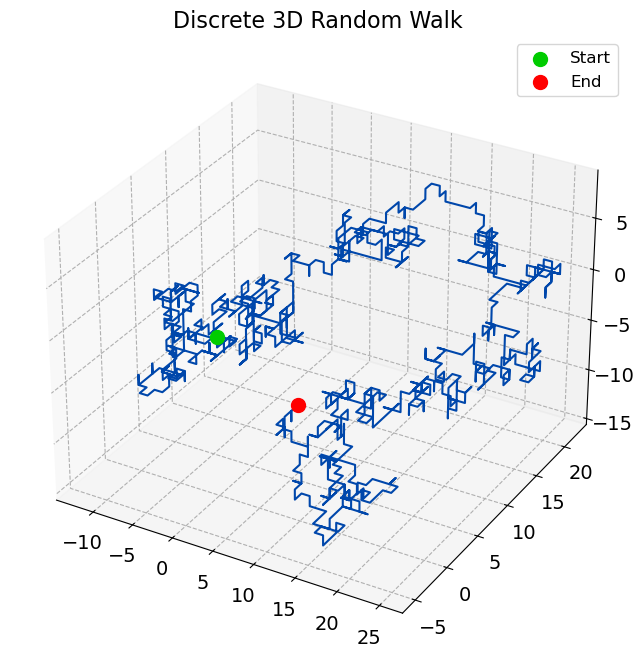

In [5]:
data = np.loadtxt("Esercizio_02.2.1/RW_disc.dat")
x = data[:, 0]
y = data[:, 1]
z = data[:, 2]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(x, y, z, lw=1.5, color=light_colors[0], alpha=1)
ax.scatter3D(x[0], y[0], z[0], color=light_colors[2], s=100, label='Start')
ax.scatter3D(x[-1], y[-1], z[-1], color=light_colors[1], s=100, label='End')

plt.title('Discrete 3D Random Walk')
plt.legend()


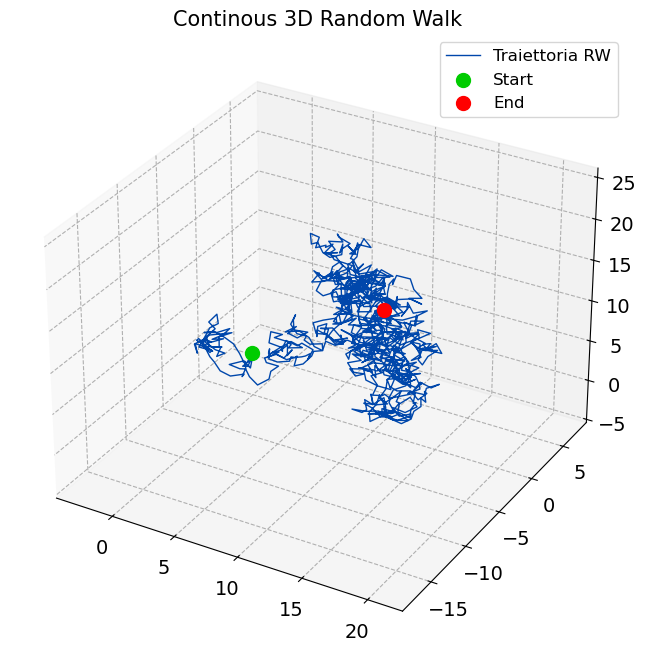

In [6]:
import matplotlib.pyplot as plt
import numpy as np
data = np.loadtxt("Esercizio_02.2.2/RW_cont.dat")
x = data[:, 0]
y = data[:, 1]
z = data[:, 2]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# 3. Disegniamo la traiettoria
ax.plot(x, y, z, lw=1, color=light_colors[0], alpha=1, label='Traiettoria RW')
ax.scatter3D(x[0], y[0], z[0], color=light_colors[2], s=100, label='Start')
ax.scatter3D(x[-1], y[-1], z[-1], color=light_colors[1], s=100, label='End')

plt.title('Continous 3D Random Walk', fontsize=15)
plt.legend()



Discrete fit: k = 1.0024 ± 0.0002
Continous fit: k = 0.9977 ± 0.0002


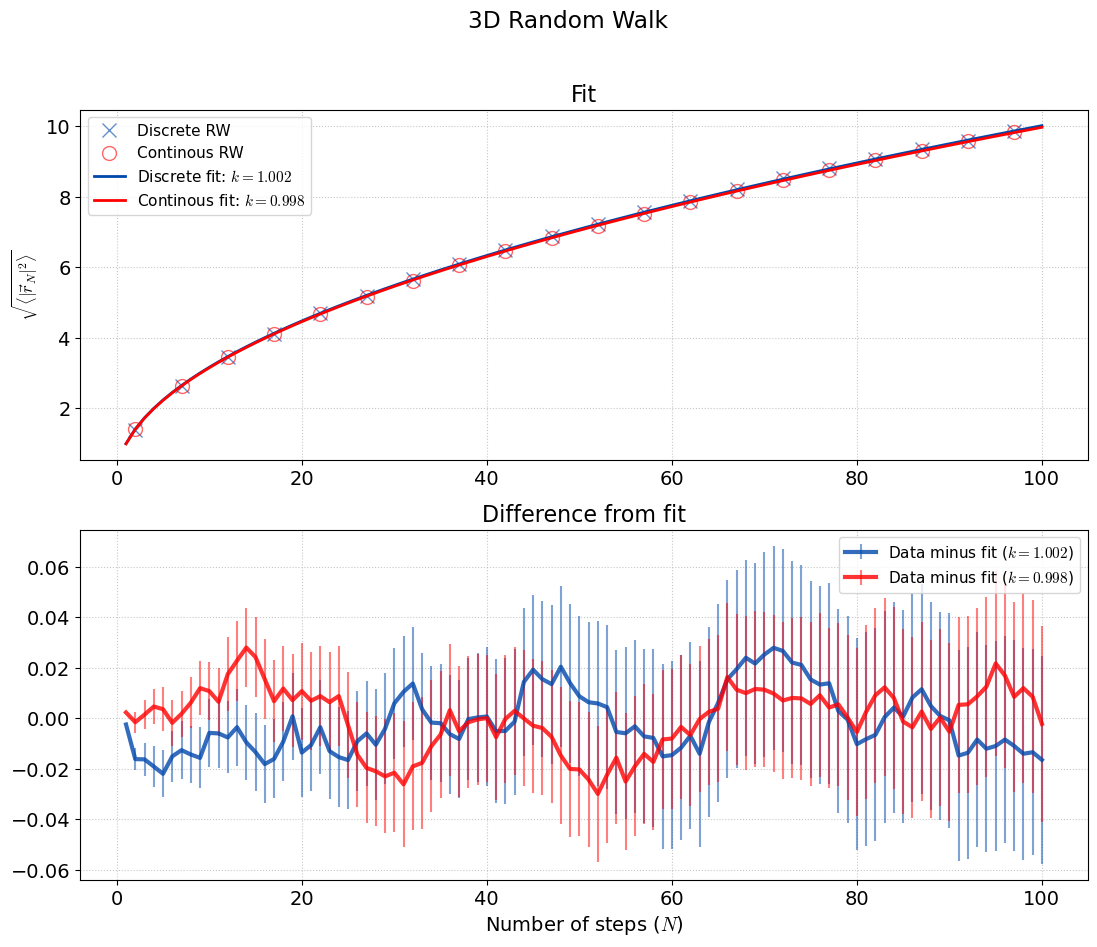

In [7]:
# 1. Funzione teorica f(N) = k * sqrt(N)
def f_fit(x, k):
    return k * np.sqrt(x)

# 2. Caricamento dati
# Caso Discreto
data_disc = np.loadtxt("Esercizio_02.2.1/esercizio_02.2.dat")
x_disc = data_disc[:, 0]
y_disc = data_disc[:, 1]
err_disc = data_disc[:, 2]

# Caso Continuo
data_cont = np.loadtxt("Esercizio_02.2.2/esercizio_02.2_cont.dat")
x_cont = data_cont[:, 0]
y_cont = data_cont[:, 1]
err_cont = data_cont[:, 2]

# 3. Esecuzione dei Fit
# Fit Discreto
popt_disc, pcov_disc = curve_fit(f_fit, x_disc, y_disc)
k_disc = popt_disc[0]
k_err_disc = np.sqrt(pcov_disc[0, 0])

# Fit Continuo
popt_cont, pcov_cont = curve_fit(f_fit, x_cont, y_cont)
k_cont = popt_cont[0]
k_err_cont = np.sqrt(pcov_cont[0, 0])

# Stampa dei risultati
print(f"Discrete fit: k = {k_disc:.4f} ± {k_err_disc:.4f}")
print(f"Continous fit: k = {k_cont:.4f} ± {k_err_cont:.4f}")

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(13, 10))
# Dati sperimentali con barre d'errore
selected = np.arange(1, 100, 5)
axes[0].plot(x_disc[selected], y_disc[selected], linestyle='none', marker='x', markersize=10, 
            # label='Dati RW Discreto', 
            color=light_colors[0], alpha=0.6) 
axes[0].plot(x_cont[selected], y_cont[selected], linestyle='none', marker='o', markerfacecolor='none', markersize=10, 
            # label='Dati RW Continuo',
            color=light_colors[1], alpha=0.6) 

# Curve di Fit
axes[0].plot(x_disc, f_fit(x_disc, *popt_disc), color=light_colors[0], linestyle='-', 
         linewidth=2, label=f'Fit Discreto: $k={k_disc:.3f}$')
axes[0].plot(x_cont, f_fit(x_cont, *popt_cont), color=light_colors[1], linestyle='-', 
         linewidth=2, label=f'Fit Continuo: $k={k_cont:.3f}$')

# Estetica
fig.suptitle('3D Random Walk')
axes[0].set_title('Fit')
#axes[0].set_xlabel('Numero di passi ($N$)', fontsize=12)
axes[0].set_ylabel(r'$\sqrt{\langle |\vec{r}_N|^2 \rangle}$', fontsize=12)
axes[0].legend(['Discrete RW', 
            'Continous RW', 
            f'Discrete fit: $k={k_disc:.3f}$', 
            f'Continous fit: $k={k_cont:.3f}$'    ],
            loc='best', fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.7)


line_c, caps_c, bars_c = axes[1].errorbar(x_disc, y_disc - f_fit(x_disc, k_disc), yerr = err_disc, linestyle='-', 
             # marker='x', markersize = 10,
         linewidth=3, label=f'Data minus fit ($k={k_disc:.3f}$)', alpha=0.8)
line_d, caps_d, bars_d = axes[1].errorbar(x_cont, y_cont - f_fit(x_cont, k_cont), yerr = err_cont, linestyle='-', 
             # marker='o', markerfacecolor='none', markersize = 10,
         linewidth=3, label=f'Data minus fit ($k={k_cont:.3f}$)', alpha=0.8)

for bar in bars_c :
    bar.set_alpha(0.5)
    bar.set_linewidth(1.5)
for bar in bars_d :
    bar.set_alpha(0.5)
    bar.set_linewidth(1.5)

# Estetica
axes[1].set_title('Difference from fit')
axes[1].set_xlabel('Number of steps ($N$)')
axes[1].legend(loc='best', fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.7)


It is clearly visible that the simulation follows a diffusive behaviour. The data fit theorical values so much that it is difficult to appreciate the difference between them. In order make it more clear, the diffference between simulation and model has been plotted too, along with the errorbars. As reported in the last image, the fluctuations from the model are very small, in the order of $10^{-2}$ over a path of lenght $10$. It is an error of roughly 0.1%. 

It is also possible to notice an increase in the errorbars, as one would expect from a simulation that lasts longer in time and space. 